# TD Séries de Fourier avec Python et Matplotlib

## Objectifs :

### Partie 1 : SIN et COS
- Construire les fonctions SIN et COS pour différentes fréquences pour t dans [-10, 10] 
- Construire les fonctions sin(n.Omega0.t) et cos(n.Omega0.t)
- Tracer les courbes correspondantes 

### Partie 2 : EXP
- Construire les fonctions EXP complexes pour différentes fréquences pour t dans [-10, 10] 
- Construire les fonctions exp(i.n.Omega0.t) pour différentes valeurs de n et Omega0
- Tracer les courbes correspondantes 

### Partie 3 : Fonction RECT
- Faire le calcul théorique des coéfficients de Fourier 
- Visualiser la fonction qui décrit les coéfficients de Fourier
- Visualiser la reconstruction de la fonction RECT par l'équation de synthèse

### Partie 4 : Calcul des coefficients de Fourier de la fonction RECT

- Utilisation de numpy.fft -> numpy.fft.fft, numpy.fft.fftshift, numpy.fft.ifft


### Partie 5 : Le cas des images : Calcul en dimension 2





In [1]:
%pip install --quiet matplotlib numpy 

# Installation pour le zoom dans les figures
%pip install --quiet ipympl


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Pour les affichages inline dans le notebook
%matplotlib inline
# Pour l'activation du Zoom
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
print("Styles disponibles (extrait):", plt.style.available[:15])
#plt.style.use("seaborn-v0_8-colorblind")
plt.style.use("classic")

plt.rcParams["font.size"] = 11  # Changement de la taille de la font par défaut
print("Taille de police par défaut:", plt.rcParams["font.size"])

print("Matplotlib:", plt.matplotlib.__version__)

Styles disponibles (extrait): ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind']
Taille de police par défaut: 11.0
Matplotlib: 3.10.6


# Quelques tests sur Numpy

In [3]:
x=range(10)
print('range(10) = ', x) 
x=np.arange(10)
print('np.arange(10) = ', x) 
x=np.arange(-5,5)
print('np.arange(-5,5) = ', x) 
x=np.arange(-5,5,0.5)
print('np.arange(-5,5,0.5) = ', x) 
x=np.linspace(-5,5,20)
print('np.linspace(-5,5,20) = ', x) 

for n in range(1,5):
    print(f"n={n}")



range(10) =  range(0, 10)
np.arange(10) =  [0 1 2 3 4 5 6 7 8 9]
np.arange(-5,5) =  [-5 -4 -3 -2 -1  0  1  2  3  4]
np.arange(-5,5,0.5) =  [-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5
  2.   2.5  3.   3.5  4.   4.5]
np.linspace(-5,5,20) =  [-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]
n=1
n=2
n=3
n=4


## Partie 1: Fonctions sin et cos

### Courbe simple (pyplot) avec labels, couleurs, titre, légendes

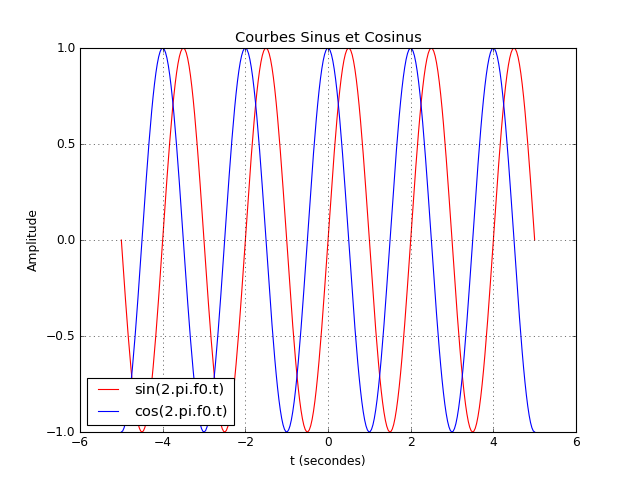

In [4]:
f0=0.5

t = np.linspace(-5, 5, 300)
ysin = np.sin(2*np.pi*f0*t)
ycos = np.cos(2*np.pi*f0*t)

plt.figure(1)
plt.clf()
plt.grid(True)
plt.plot(t, ysin, label="sin(2.pi.f0.t)", color="#FF0000")
plt.plot(t, ycos, label="cos(2.pi.f0.t)")
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.title("Courbes Sinus et Cosinus")
plt.legend(loc="lower left")

plt.show()

## Courbes Sin(n Omega0 t) et Cos(n Omega0 t) pour différentes valeurs de n

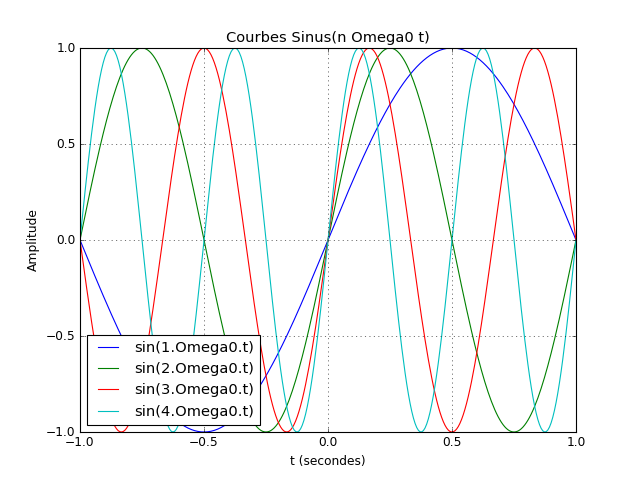

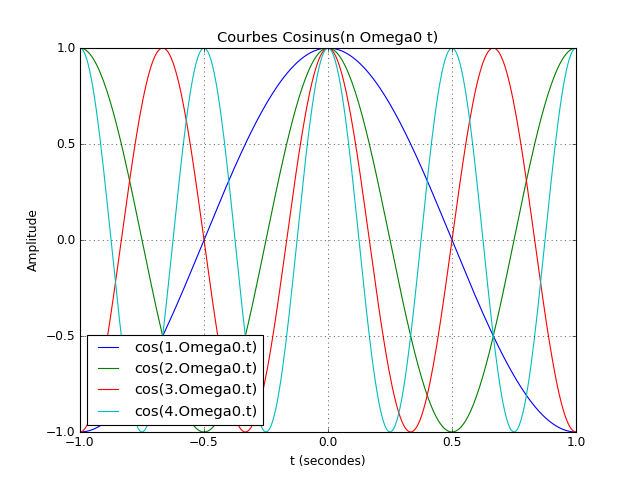

In [5]:
f0=0.5
t = np.linspace(-1, 1, 300)

# Courbes Sinus
plt.figure(2)
plt.clf()
plt.grid(True)
for n in range(1,5):
    ysin = np.sin(n*2*np.pi*f0*t)
    plt.plot(t, ysin, label=f"sin({n}.Omega0.t)")
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.title("Courbes Sinus(n Omega0 t)")
plt.legend(loc="lower left")
plt.show()

# Courbes Cosinus
plt.figure(3)
plt.clf()
plt.grid(True)
for n in range(1,5):
    ycos = np.cos(n*2*np.pi*f0*t)
    plt.plot(t, ycos, label=f"cos({n}.Omega0.t)")
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.title("Courbes Cosinus(n Omega0 t)")
plt.legend(loc="lower left")
plt.show()


## Partie 2: Fonction exponentielle

### Courbes exp(n Omega0 t) pour différentes valeurs de n
- avec partie réelle/partie imaginaire
- en 3D

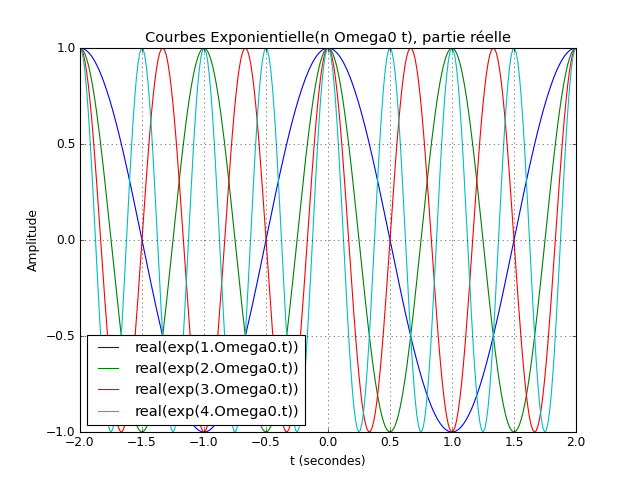

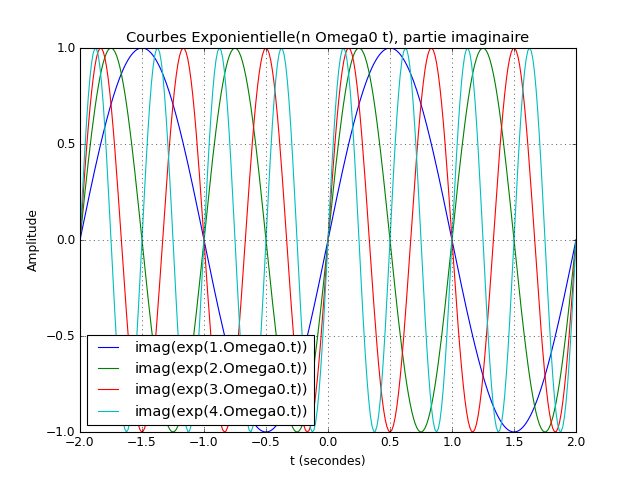

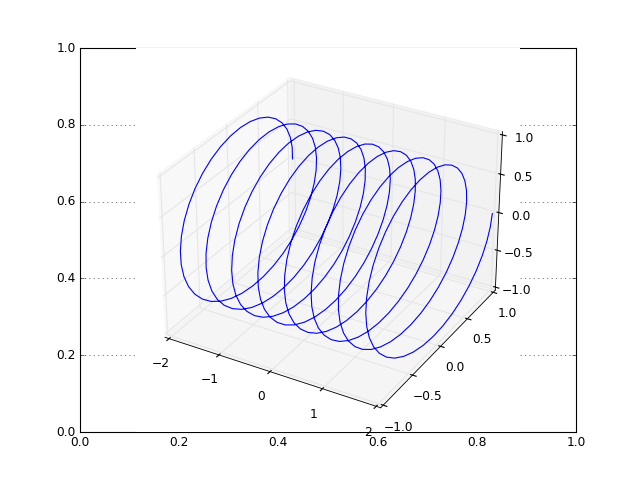

In [6]:
f0=0.5
t = np.linspace(-2, 2, 300)

plt.figure(4)
plt.clf()
plt.grid(True)
plt.figure(5)
plt.clf()
plt.grid(True)

# Courbes exponentielles
i=1j
for n in range(1,5):
    yexp = np.exp(i*n*2*np.pi*f0*t)
    plt.figure(4)
    plt.plot(t, np.real(yexp), label=f"real(exp({n}.Omega0.t))")
    plt.figure(5)
    plt.plot(t, np.imag(yexp), label=f"imag(exp({n}.Omega0.t))")

plt.figure(4)    
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.title("Courbes Exponientielle(n Omega0 t), partie réelle")
plt.legend(loc="lower left")
plt.show()

plt.figure(5)    
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.title("Courbes Exponientielle(n Omega0 t), partie imaginaire")
plt.legend(loc="lower left")
plt.show()

plt.figure(6)
plt.clf()
plt.grid(True)
axes = plt.axes(projection="3d")
#print(axes, type(axes))

# Tracer les lignes en 3D
axes.plot(t, np.real(yexp), np.imag(yexp))
plt.show()


## Partie 3 : Fonction RECT
- Faire le calcul théorique des coéfficients de Fourier 
- Visualiser la fonction qui décrit les coéfficients de Fourier
- Visualiser la reconstruction de la fonction RECT par l'équation de synthèse

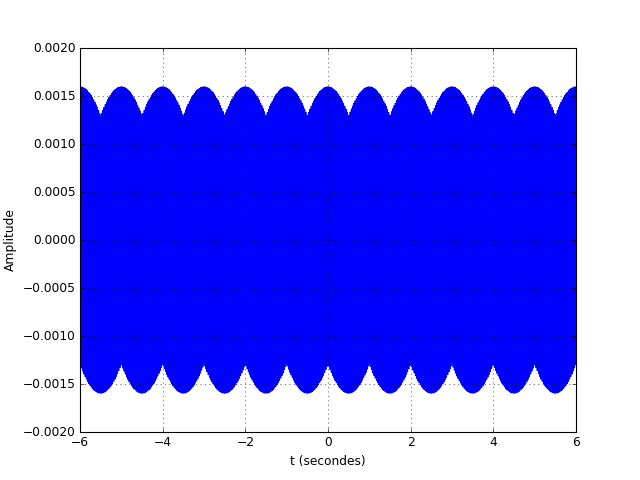

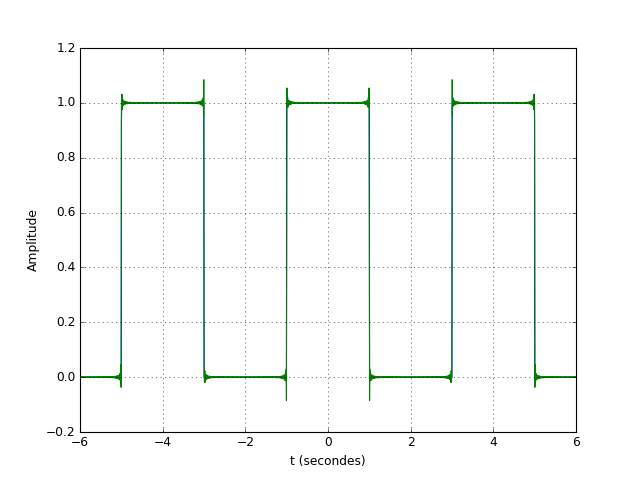

In [7]:
t=np.linspace(-6,6,2000)
rect=np.round(0.5+0.5*np.cos(2*np.pi*0.25*t))

N=400

f=0.5*np.ones(2000)
for n in range(1,N):
    fn=np.sin(n*np.pi/2)/(n*np.pi/2) * np.cos(n*np.pi/2*t)
    f=f+fn
    
plt.figure(7)
plt.clf()
plt.grid(True)
plt.plot(t,fn)
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(8)
plt.clf()
plt.grid(True)
plt.plot(t,rect)
plt.plot(t,f)
plt.xlabel("t (secondes)")
plt.ylabel("Amplitude")
plt.show()

## Partie 4.1 : Calcul des coefficients de Fourier de la fonction RECT

/home/steph/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/steph/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/steph/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


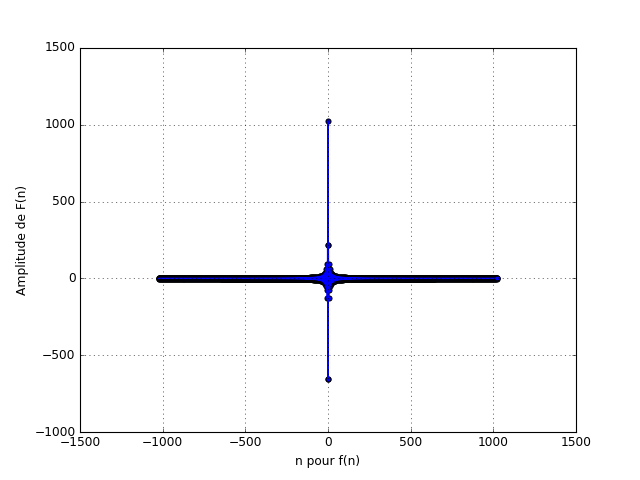

In [8]:
N=2048
a=-2
b=2
T0=4
Te=(b-a)/N
t=np.zeros(N)
absn=np.zeros(N)

for n in range(N):
    t[n]=n*Te+a
    absn[n]=-N/2+n
    
rect=np.round(0.5+0.5*np.cos(2*np.pi*0.25*t))

Frect=np.zeros(N, dtype=complex)
Frect=np.fft.fft(rect)
Frect=np.fft.fftshift(Frect)

plt.figure(9)
plt.clf()
plt.grid(True)
plt.plot(absn,Frect)
plt.scatter(absn,Frect)

plt.xlabel("n pour f(n)")
plt.ylabel("Amplitude de F(n)")
plt.show()


## Partie 4.2 : Reconstruction de la fonction rect à partir des coefficients de Fourier

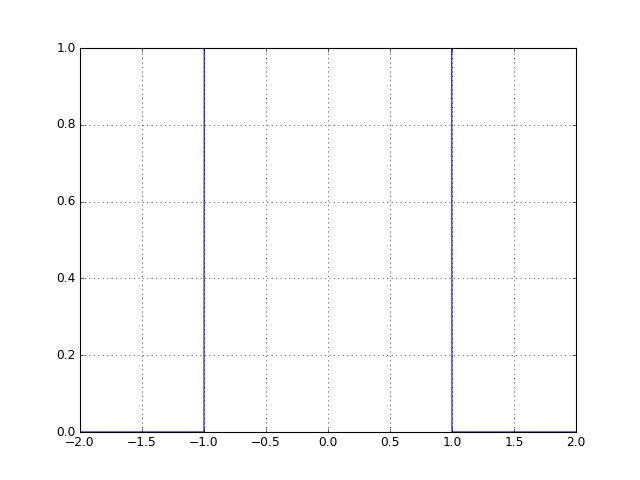

In [9]:
iFrect=np.fft.fftshift(Frect)
rect=np.fft.ifft(iFrect)

plt.figure(10)
plt.clf()
plt.grid(True)

plt.plot(t,rect)
plt.show()


## Partie 4.3 : Filtrage passe-bas 
- Suppression des coefficients de valeurs absolues les plus élevées

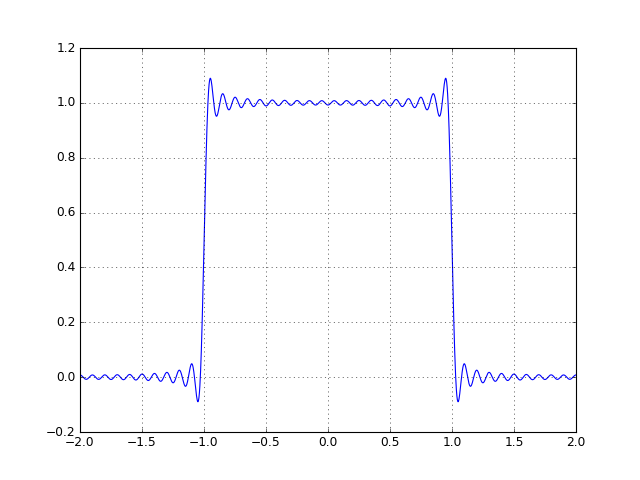

In [10]:
SeuilPB=40
FrectPB=np.zeros(N, dtype=complex)
FrectPB[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]=Frect[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]
iFrectPB=np.fft.fftshift(FrectPB)
rectPB=np.fft.ifft(iFrectPB)

plt.figure(11)
plt.clf()
plt.grid(True)

plt.plot(t,rectPB)
plt.show()

## Partie 4.4 : Filtrage passe-haut 
- Suppression des coefficients de valeurs absolues les plus basses

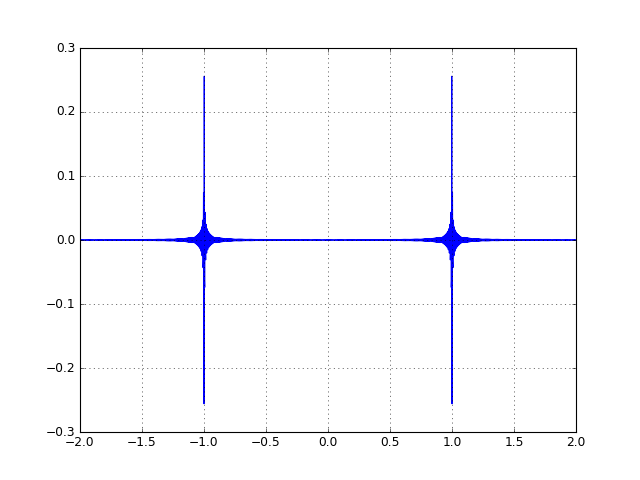

In [11]:
SeuilPH=500
FrectPH=Frect.copy()
FrectPH[int(N/2+1-SeuilPH):int(N/2+1+SeuilPH)]=0
iFrectPH=np.fft.fftshift(FrectPH)
rectPH=np.fft.ifft(iFrectPH)

plt.figure(12)
plt.clf()
plt.grid(True)

plt.plot(t,rectPH)
plt.show()

## Partie 5 : Test sur une fonction f(t) observée sur un intervalle  [-2,2]
- Construction d'une fonction avec des variations et du bruit

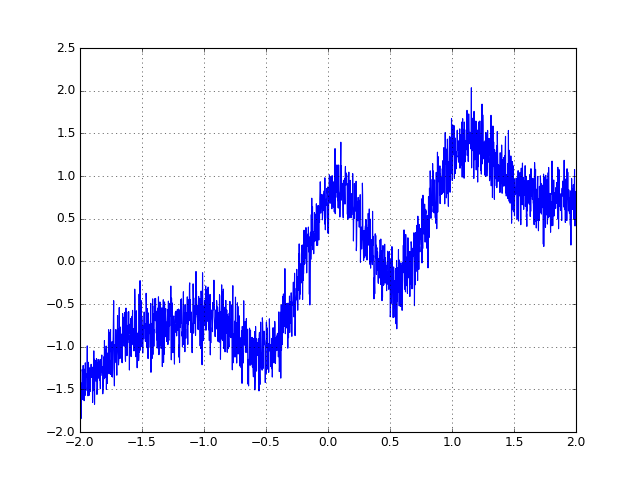

In [12]:
rng = np.random.default_rng(42)

N=2048
a=-2
b=2
T0=4
Te=(b-a)/N
t=np.zeros(N)
absn=np.zeros(N)

for n in range(N):
    t[n]=n*Te+a
    absn[n]=-N/2+n
    
f=np.sin(t)+0.5*np.cos(5*t)+0.3*np.sin(7*t+1)+0.2*rng.normal(0, 1, N)

plt.figure(13)
plt.clf()
plt.grid()
plt.plot(t,f)
plt.show()


### Calcul des coéfficients de Fourier et affichage

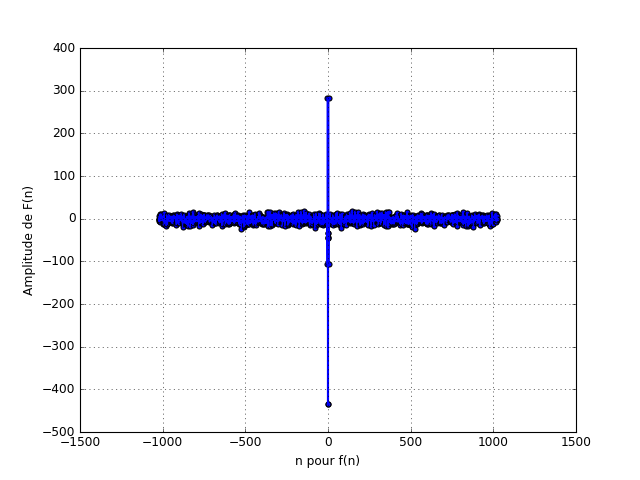

In [13]:
Ff=np.fft.fft(f)
Ff=np.fft.fftshift(Ff)

plt.figure(14)
plt.clf()
plt.grid(True)
plt.plot(absn,Ff)
plt.scatter(absn,Ff)

plt.xlabel("n pour f(n)")
plt.ylabel("Amplitude de F(n)")
plt.show()

## Filtrage passe bas et affichage du résultat

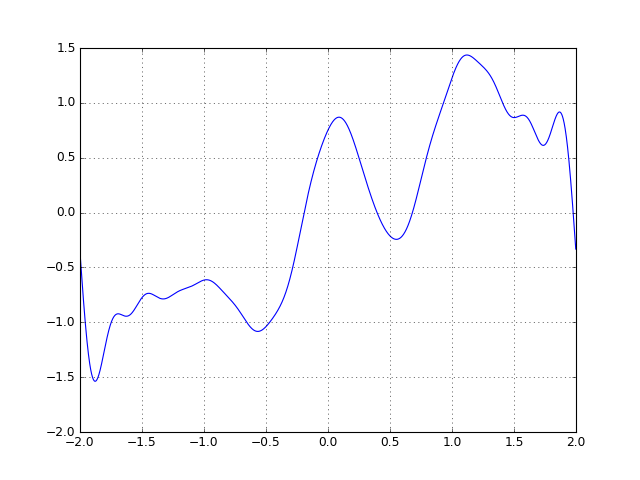

In [14]:
SeuilPB=15
# ATTENTION : Initialisation de la variable en type COMPLEXE pour bien conserver 
#             l'ensemble des informations réelles ET complexes
FfPB=np.zeros(N, dtype=complex)
FfPB[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]=Ff[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]
iFfPB=np.fft.fftshift(FfPB)
fPB=np.fft.ifft(iFfPB)

plt.figure(15)
plt.clf()
plt.grid(True)

plt.plot(t,fPB)
plt.show()